   edge_density  tumor_area  tumor_perimeter  circularity  glcm_contrast  \
0       7.83062      1059.5        276.00714     0.174771       0.101108   

   glcm_energy  glcm_homogeneity  glcm_correlation  
0     0.494275          0.953143          0.996065  


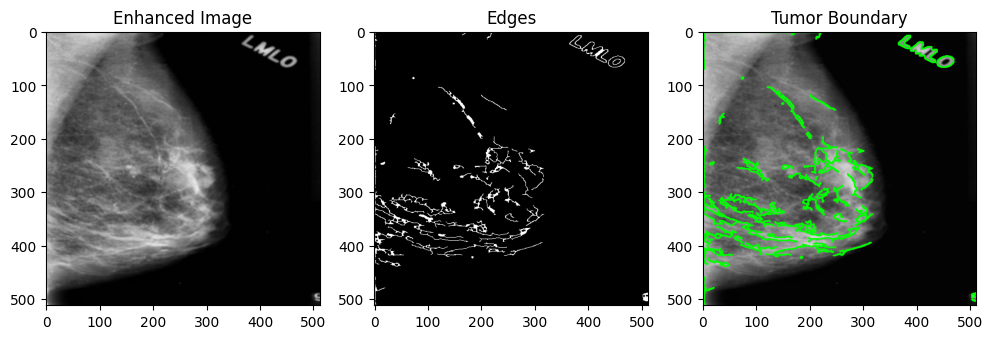

In [1]:
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt


img = cv2.imread("mammogram.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (512,512))

blur = cv2.GaussianBlur(img, (5,5), 0)

# contrast enhancement
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(blur)

# 3. Edge Detection (Canny)
edges = cv2.Canny(enhanced, 50, 150)
kernel = np.ones((3,3), np.uint8)
edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
edge_density = np.sum(edges_closed) / (512*512)
contours, _ = cv2.findContours(edges_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

perimeter = 0
area = 0
circularity = 0

if len(contours) > 0:
    c = max(contours, key=cv2.contourArea)
    perimeter = cv2.arcLength(c, True)
    area = cv2.contourArea(c)

    if perimeter != 0:
        circularity = 4*np.pi*area/(perimeter**2)

quantized = (enhanced / 16).astype(np.uint8)

glcm = graycomatrix(
        quantized,
        distances=[1],
        angles=[0],
        levels=16,
        symmetric=True,
        normed=True
      )

contrast = graycoprops(glcm, 'contrast')[0,0]
energy = graycoprops(glcm, 'energy')[0,0]
homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
correlation = graycoprops(glcm, 'correlation')[0,0]

features = {
    "edge_density": edge_density,
    "tumor_area": area,
    "tumor_perimeter": perimeter,
    "circularity": circularity,
    "glcm_contrast": contrast,
    "glcm_energy": energy,
    "glcm_homogeneity": homogeneity,
    "glcm_correlation": correlation
}

df = pd.DataFrame([features])
print(df)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Enhanced Image")
plt.imshow(enhanced, cmap='gray')

plt.subplot(1,3,2)
plt.title("Edges")
plt.imshow(edges_closed, cmap='gray')

plt.subplot(1,3,3)
plt.title("Tumor Boundary")
img_color = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_color, contours, -1, (0,255,0), 2)
plt.imshow(img_color[:,:,::-1])

plt.show()

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

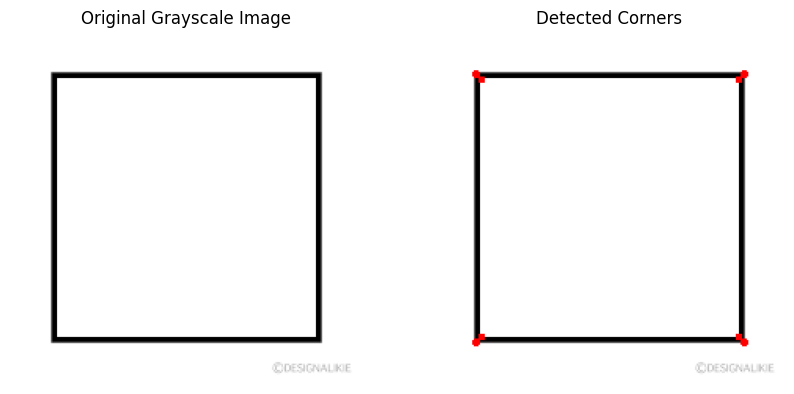

In [17]:

img = cv2.imread('E:\Computer Vision\LAB\lab06\images.png', 0)

gray = np.float32(img)
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

dst = cv2.dilate(dst, None)
threshold = 0.01 * dst.max()
img_color[dst > threshold] = [255, 0, 0]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Grayscale Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Detected Corners")
plt.imshow(img_color)
plt.axis('off')

plt.show()

In [2]:
import cv2
import numpy as np
import time

VIDEO_SOURCE = 0
cap = cv2.VideoCapture(VIDEO_SOURCE)

if not cap.isOpened():
    print("Error opening video stream")
    exit()

blockSize = 2        
ksize = 3            
k = 0.04             # Harris constant
threshold_ratio = 0.01   # corner threshold

print("Controls:")
print("Q/A -> Increase/Decrease Threshold")
print("W/S -> Increase/Decrease blockSize")
print("E/D -> Increase/Decrease k")
print("ESC -> Exit")

prev_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (640, 480))


    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    gray = cv2.GaussianBlur(gray, (5,5), 1)

    dst = cv2.cornerHarris(gray, blockSize, ksize, k)
    dst = cv2.dilate(dst, None)
    threshold = threshold_ratio * dst.max()
    frame[dst > threshold] = [0,0,255]

    curr_time = time.time()
    fps = 1/(curr_time - prev_time)
    prev_time = curr_time

    cv2.putText(frame, f"FPS: {int(fps)}", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.putText(frame,
                f"T:{threshold_ratio:.3f} B:{blockSize} k:{k:.3f}",
                (20,80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

    cv2.imshow("Harris Corners Real-Time", frame)
    key = cv2.waitKey(1) & 0xFF

    if key == 27:   # ESC
        break

    elif key == ord('q'):
        threshold_ratio += 0.005

    elif key == ord('a'):
        threshold_ratio = max(0.001, threshold_ratio - 0.005)

    elif key == ord('w'):
        blockSize += 2
        if blockSize % 2 == 0:
            blockSize += 1

    elif key == ord('s'):
        blockSize = max(2, blockSize - 2)

    elif key == ord('e'):
        k += 0.005

    elif key == ord('d'):
        k = max(0.01, k - 0.005)

cap.release()
cv2.destroyAllWindows()

Controls:
Q/A -> Increase/Decrease Threshold
W/S -> Increase/Decrease blockSize
E/D -> Increase/Decrease k
ESC -> Exit


Total Keypoints Detected: 532
Descriptor Shape: (532, 128)

Keypoint 1
Location (x,y): (73.24249267578125, 188.159912109375)
Scale: 8.810149192810059
Orientation (deg): 7.5238037109375
Response: 0.06860252469778061

Keypoint 2
Location (x,y): (81.25347137451172, 178.25228881835938)
Scale: 3.870131015777588
Orientation (deg): 185.61538696289062
Response: 0.013833895325660706

Keypoint 3
Location (x,y): (84.80082702636719, 228.00064086914062)
Scale: 4.956000804901123
Orientation (deg): 331.3199768066406
Response: 0.029748830944299698

Keypoint 4
Location (x,y): (86.97821044921875, 214.34707641601562)
Scale: 2.805917739868164
Orientation (deg): 128.7743377685547
Response: 0.019089557230472565

Keypoint 5
Location (x,y): (89.0584487915039, 141.5567169189453)
Scale: 3.3341190814971924
Orientation (deg): 38.124969482421875
Response: 0.03263501822948456


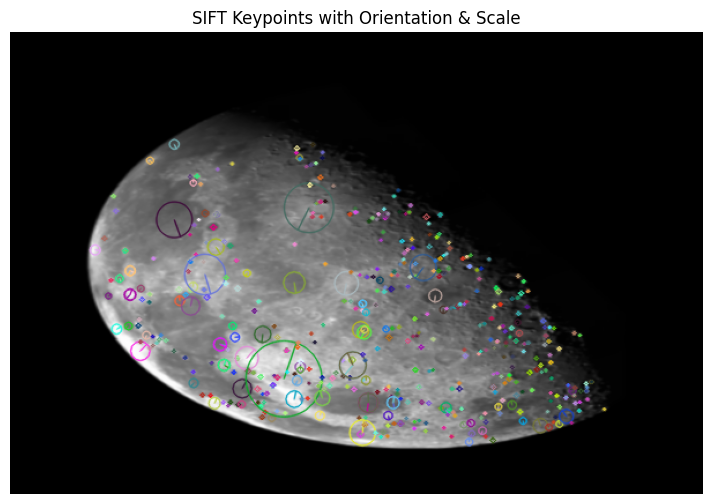

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Fig03.tif", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not found")
    exit()

img = cv2.resize(img, (600, 400))


sift = cv2.SIFT_create(
        nfeatures=0,
        nOctaveLayers=3,
        contrastThreshold=0.04,
        edgeThreshold=10,
        sigma=1.6
      )

keypoints, descriptors = sift.detectAndCompute(img, None)

print("Total Keypoints Detected:", len(keypoints))
print("Descriptor Shape:", descriptors.shape)

img_kp = cv2.drawKeypoints(
            img,
            keypoints,
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
         )

for i, kp in enumerate(keypoints[:5]):
    print(f"\nKeypoint {i+1}")
    print("Location (x,y):", kp.pt)
    print("Scale:", kp.size)
    print("Orientation (deg):", kp.angle)
    print("Response:", kp.response)

plt.figure(figsize=(10,6))
plt.title("SIFT Keypoints with Orientation & Scale")
plt.imshow(img_kp, cmap='gray')
plt.axis("off")
plt.show()